# 02 — The Naive Join

**Project:** Marketing Attribution & Systems-Integration Analysis

## Purpose

Notebook 01 profiled each system separately and found six structural obstacles. This notebook
does the thing an analyst under time pressure would actually do: **attempt the join anyway**,
with no reconciliation, and measure precisely how badly it fails.

This is not a strawman. Producing the failing number is the deliverable. "The join doesn't work"
is an opinion; "the join matches 0% of rows and leaves \$10.0M of revenue unattributed" is a
finding that justifies engineering time.

## What we are joining, and why it is the only option

From notebook 01, by elimination:

| Candidate key | Why it fails |
|---|---|
| Campaign ID | Does not exist in ads data |
| Customer / account ID | Does not exist in ads data |
| Date | Zero overlapping days between systems |
| Country / geography | CRM has `office_location` (HQ country), ads has campaign target country — different concepts |
| Platform / channel | CRM has no channel field at all |
| **Industry ↔ sector** | **Only remaining candidate** |

So: `ads.industry` ↔ `accounts.sector`. We already know these share zero exact values. Let's
quantify the damage rather than assert it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
sns.set_theme(style='whitegrid')

ads = pd.read_parquet('../data/clean/ads_typed.parquet')
crm = pd.read_parquet('../data/clean/crm_enriched.parquet')

print("ads:", ads.shape)
print("crm:", crm.shape)

ads: (1800, 14)
crm: (8800, 12)


---

## Step 1 — State the assumptions explicitly

Before joining, we have to decide what to do about the date problem. Being explicit here is the
difference between an analysis and a fabrication.

### Assumption A1 — Time alignment is abandoned, not faked

Ads cover 2024; CRM covers 2016–17. There is no overlap and no honest way to create one.

We could re-anchor CRM dates onto the 2024 calendar to make the periods appear to line up. **We
will not do this.** It would manufacture a temporal relationship that does not exist, and every
downstream number would inherit that fiction while looking perfectly legitimate.

Instead we treat both datasets as **cross-sectional aggregates over their respective full
periods**. The question shifts from *"did this week's spend produce next month's deals?"* to
*"how does the industry mix of ad investment compare to the industry mix of closed revenue?"*

That is a weaker question. It is also the strongest question this data can honestly support.

### Assumption A2 — Sector is a proxy for campaign targeting

We assume a deal from a `finance`-sector account is plausibly influenced by ads targeted at the
`Fintech` industry. This is an assumption about *audience overlap*, not proof of causation.
Nothing here establishes that any specific ad produced any specific deal.

### Assumption A3 — Closed-won revenue is the revenue measure

`close_value` on `Won` deals. `Lost` deals contribute \$0; open deals are excluded from revenue
(they have null `close_value`) but retained for pipeline counts.

### What this analysis explicitly cannot do

- Attribute revenue to a **platform** (Google vs Meta vs TikTok) — the CRM has no channel field
- Attribute revenue to an individual **deal** or **customer** — ads data has no identifiers
- Measure **time-lagged** effects — no date overlap
- Establish **causation** — this is descriptive mix comparison only

In [2]:
# Encode the assumptions as an object carried through the analysis
ASSUMPTIONS = {
    'A1_time': 'No date alignment; both sides treated as cross-sectional totals over their own period',
    'A2_key':  'ads.industry <-> accounts.sector as an audience-overlap proxy',
    'A3_rev':  'Revenue = sum(close_value) where deal_stage == "Won"',
}
for k, v in ASSUMPTIONS.items():
    print(f"{k}: {v}")

A1_time: No date alignment; both sides treated as cross-sectional totals over their own period
A2_key: ads.industry <-> accounts.sector as an audience-overlap proxy
A3_rev: Revenue = sum(close_value) where deal_stage == "Won"


---

## Step 2 — Aggregate each side to a joinable grain

Neither side can be joined at its native grain: ads rows are dimension-combinations, CRM rows
are individual deals. Both must be rolled up to **one row per industry/sector**.

Ratio metrics are recomputed from summed components — never averaged. (Notebook 01 showed the
error this avoids.)

In [3]:
ads_by_industry = ads.groupby('industry', as_index=False).agg(
    ad_spend=('ad_spend', 'sum'),
    ad_revenue=('revenue', 'sum'),
    impressions=('impressions', 'sum'),
    clicks=('clicks', 'sum'),
    conversions=('conversions', 'sum'),
    n_ad_rows=('industry', 'size'),
)

# Recompute ratios from the sums
ads_by_industry['ROAS'] = ads_by_industry['ad_revenue'] / ads_by_industry['ad_spend']
ads_by_industry['CPA'] = ads_by_industry['ad_spend'] / ads_by_industry['conversions']
ads_by_industry['CTR'] = ads_by_industry['clicks'] / ads_by_industry['impressions']

print("Ads side — one row per industry:")
ads_by_industry.round(2)

Ads side — one row per industry:


,industry,ad_spend,ad_revenue,impressions,clicks,conversions,n_ad_rows,ROAS,CPA,CTR
0,E-commerce,1923987.08,9637279.69,33800712,1280139,57486,349,5.01,33.47,0.04
1,EdTech,2296978.52,11549934.43,39833845,1502152,67257,372,5.03,34.15,0.04
2,Fintech,2271537.73,10173311.23,36966664,1412347,65121,361,4.48,34.88,0.04
3,Healthcare,2258683.92,10930814.04,36619145,1387123,65687,348,4.84,34.39,0.04
4,SaaS,2357561.84,11891991.42,38033868,1551055,71261,370,5.04,33.08,0.04


In [4]:
won = crm[crm['deal_stage'] == 'Won']

crm_by_sector = crm.groupby('sector', as_index=False).agg(
    total_deals=('opportunity_id', 'count'),
    n_accounts=('account', 'nunique'),
)

won_agg = won.groupby('sector', as_index=False).agg(
    deals_won=('opportunity_id', 'count'),
    crm_revenue=('close_value', 'sum'),
    avg_deal_size=('close_value', 'mean'),
)

crm_by_sector = crm_by_sector.merge(won_agg, on='sector', how='left')

print("CRM side — one row per sector:")
crm_by_sector.round(2)

CRM side — one row per sector:


,sector,total_deals,n_accounts,deals_won,crm_revenue,avg_deal_size
0,employment,311,4,179,436174.0,2436.73
1,entertainment,451,6,260,689007.0,2650.03
2,finance,678,8,375,950908.0,2535.75
3,marketing,674,8,404,922321.0,2282.97
4,medical,1051,12,592,1359595.0,2296.61
5,retail,1397,17,799,1867528.0,2337.33
6,services,390,5,223,533006.0,2390.16
7,software,757,7,450,1077934.0,2395.41
8,technolgy,1165,12,671,1515487.0,2258.55
9,telecommunications,501,6,285,653574.0,2293.24


In [5]:
# Sanity check: no revenue lost in aggregation
print(f"Total won revenue (raw):        ${won['close_value'].sum():,.2f}")
print(f"Total won revenue (aggregated): ${crm_by_sector['crm_revenue'].sum():,.2f}")
print(f"Reconciles: {np.isclose(won['close_value'].sum(), crm_by_sector['crm_revenue'].sum())}")

print(f"\nTotal ad spend (raw):        ${ads['ad_spend'].sum():,.2f}")
print(f"Total ad spend (aggregated): ${ads_by_industry['ad_spend'].sum():,.2f}")
print(f"Reconciles: {np.isclose(ads['ad_spend'].sum(), ads_by_industry['ad_spend'].sum())}")

Total won revenue (raw):        $10,005,534.00
Total won revenue (aggregated): $10,005,534.00
Reconciles: True

Total ad spend (raw):        $11,108,749.09
Total ad spend (aggregated): $11,108,749.09
Reconciles: True


---

## Step 3 — The naive join

Merge on the raw string values, exactly as a first-pass attempt would.

In [6]:
naive = ads_by_industry.merge(
    crm_by_sector,
    left_on='industry',
    right_on='sector',
    how='outer',
    indicator=True,
)

print("Merge result:")
naive[['industry', 'sector', 'ad_spend', 'crm_revenue', '_merge']]

Merge result:


,industry,sector,ad_spend,crm_revenue,_merge
0,E-commerce,NaN,1923987.08,NaN,left_only
1,EdTech,NaN,2296978.52,NaN,left_only
2,Fintech,NaN,2271537.73,NaN,left_only
3,Healthcare,NaN,2258683.92,NaN,left_only
4,SaaS,NaN,2357561.84,NaN,left_only
5,NaN,employment,NaN,436174.0,right_only
6,NaN,entertainment,NaN,689007.0,right_only
7,NaN,finance,NaN,950908.0,right_only
8,NaN,marketing,NaN,922321.0,right_only
9,NaN,medical,NaN,1359595.0,right_only


In [7]:
print("=" * 55)
print("MATCH DIAGNOSTICS")
print("=" * 55)

counts = naive['_merge'].value_counts()
print(counts.to_string())

matched = (naive['_merge'] == 'both').sum()
print(f"\nRows matching on both sides: {matched}")
print(f"Match rate: {matched / len(naive):.1%}")

MATCH DIAGNOSTICS
_merge
right_only    10
left_only      5
both           0

Rows matching on both sides: 0
Match rate: 0.0%


### The headline number

In [8]:
n_ads_industries = ads_by_industry['industry'].nunique()
n_crm_sectors = crm_by_sector['sector'].nunique()

total_spend = ads_by_industry['ad_spend'].sum()
total_crm_rev = crm_by_sector['crm_revenue'].sum()

matched_rows = naive[naive['_merge'] == 'both']
matched_spend = matched_rows['ad_spend'].sum()
matched_rev = matched_rows['crm_revenue'].sum()

print("=" * 62)
print("NAIVE JOIN — RESULT")
print("=" * 62)
print(f"Ads industries:              {n_ads_industries}")
print(f"CRM sectors:                 {n_crm_sectors}")
print(f"Successfully matched:        {matched}")
print()
print(f"Ad spend total:              ${total_spend:>14,.2f}")
print(f"Ad spend matched to CRM:     ${matched_spend:>14,.2f}   ({matched_spend/total_spend:.1%})")
print(f"Ad spend UNMATCHED:          ${total_spend - matched_spend:>14,.2f}   ({1 - matched_spend/total_spend:.1%})")
print()
print(f"CRM revenue total:           ${total_crm_rev:>14,.2f}")
print(f"CRM revenue matched to ads:  ${matched_rev:>14,.2f}   ({matched_rev/total_crm_rev:.1%})")
print(f"CRM revenue UNMATCHED:       ${total_crm_rev - matched_rev:>14,.2f}   ({1 - matched_rev/total_crm_rev:.1%})")
print("=" * 62)

NAIVE JOIN — RESULT
Ads industries:              5
CRM sectors:                 10
Successfully matched:        0

Ad spend total:              $ 11,108,749.09
Ad spend matched to CRM:     $          0.00   (0.0%)
Ad spend UNMATCHED:          $ 11,108,749.09   (100.0%)

CRM revenue total:           $ 10,005,534.00
CRM revenue matched to ads:  $          0.00   (0.0%)
CRM revenue UNMATCHED:       $ 10,005,534.00   (100.0%)


### Interpretation

A **0% match rate.** Not degraded, not partial — total failure. Every dollar of ad spend and
every dollar of closed revenue falls on the unmatched side.

The join executed without error. `pd.merge` raised no exception, returned a well-formed
DataFrame with the expected columns, and would slot happily into a pipeline. **A silent
failure is the dangerous kind** — had we used an inner join, the result would have been an
empty DataFrame; had we used a left join and only checked the row count, everything would have
looked fine while every CRM column came back null.

In [9]:
# What an inner join would have produced
inner = ads_by_industry.merge(crm_by_sector, left_on='industry', right_on='sector', how='inner')
print(f"Inner join returns {len(inner)} rows — an empty DataFrame, silently.")

# What a left join would have produced
left = ads_by_industry.merge(crm_by_sector, left_on='industry', right_on='sector', how='left')
print(f"\nLeft join returns {len(left)} rows — looks correct by row count alone.")
print(f"But crm_revenue is null in {left['crm_revenue'].isnull().sum()} of {len(left)} rows ({left['crm_revenue'].isnull().mean():.0%}).")
print("\nThis is why row count is never a sufficient validation of a join.")

Inner join returns 0 rows — an empty DataFrame, silently.

Left join returns 5 rows — looks correct by row count alone.
But crm_revenue is null in 5 of 5 rows (100%).

This is why row count is never a sufficient validation of a join.


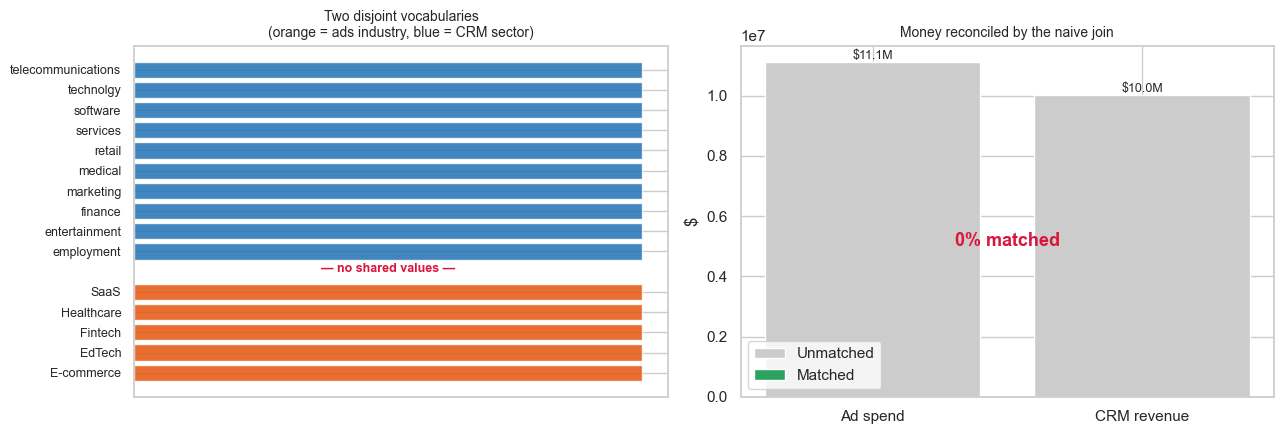

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: unmatched values on each side
ax = axes[0]
ads_vals = sorted(ads_by_industry['industry'])
crm_vals = sorted(crm_by_sector['sector'])
ax.barh(range(len(ads_vals)), [1]*len(ads_vals), color='#e6550d', alpha=0.85)
ax.barh([i + len(ads_vals) + 1 for i in range(len(crm_vals))], [1]*len(crm_vals),
        color='#2171b5', alpha=0.85)
ax.set_yticks(list(range(len(ads_vals))) + [i + len(ads_vals) + 1 for i in range(len(crm_vals))])
ax.set_yticklabels(ads_vals + crm_vals, fontsize=9)
ax.set_xticks([])
ax.set_title('Two disjoint vocabularies\n(orange = ads industry, blue = CRM sector)', fontsize=10)
ax.text(0.5, len(ads_vals) - 0.5 + 0.5, '— no shared values —',
        ha='center', color='crimson', fontsize=9, fontweight='bold')

# Right: matched vs unmatched money
ax = axes[1]
bars = ax.bar(['Ad spend', 'CRM revenue'],
              [total_spend, total_crm_rev],
              color='#cccccc', label='Unmatched')
ax.bar(['Ad spend', 'CRM revenue'], [matched_spend, matched_rev],
       color='#2ca25f', label='Matched')
ax.set_ylabel('$')
ax.set_title('Money reconciled by the naive join', fontsize=10)
ax.legend()
for b, v in zip(bars, [total_spend, total_crm_rev]):
    ax.text(b.get_x() + b.get_width()/2, v, f'${v/1e6:.1f}M',
            ha='center', va='bottom', fontsize=9)
ax.text(0.5, max(total_spend, total_crm_rev) * 0.45, '0% matched',
        ha='center', transform=ax.transData, color='crimson',
        fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

---

## Step 4 — Rule out the easy fixes

Before concluding a crosswalk is necessary, we should verify that cheaper solutions genuinely
don't work. A reviewer will ask, so we answer preemptively.

In [11]:
def try_normalise(fn, label):
    a = set(fn(v) for v in ads_by_industry['industry'])
    c = set(fn(v) for v in crm_by_sector['sector'])
    overlap = a & c
    print(f"{label:<42} matches: {len(overlap)}  {sorted(overlap) if overlap else ''}")
    return len(overlap)

print("Attempting cheap string normalisations:\n")
try_normalise(lambda s: s.lower(), "lowercase")
try_normalise(lambda s: s.lower().strip(), "lowercase + strip")
try_normalise(lambda s: s.lower().replace('-', '').replace(' ', ''), "lowercase + remove punctuation/space")
try_normalise(lambda s: s.lower()[:4], "lowercase + first 4 chars")

print("\nNone of these recover a single match.")

Attempting cheap string normalisations:

lowercase                                  matches: 0  
lowercase + strip                          matches: 0  
lowercase + remove punctuation/space       matches: 0  
lowercase + first 4 chars                  matches: 0  

None of these recover a single match.


In [12]:
# Fuzzy matching — the tool most people reach for next
from thefuzz import process, fuzz

ads_vals = sorted(ads_by_industry['industry'])
crm_vals = sorted(crm_by_sector['sector'])

print("Fuzzy match: each ads industry vs. all CRM sectors\n")
print(f"{'ads industry':<13} {'best fuzzy match':<18} {'score':>6}   {'human-correct answer':<12} {'agree?'}")
print("-" * 74)

human_map = {
    'Fintech': 'finance',
    'Healthcare': 'medical',
    'SaaS': 'software',
    'E-commerce': 'retail',
    'EdTech': None,
}

fuzzy_correct = 0
for ind in ads_vals:
    match, score = process.extractOne(ind, crm_vals, scorer=fuzz.token_sort_ratio)
    truth = human_map[ind]
    agree = (match == truth)
    fuzzy_correct += agree
    print(f"{ind:<13} {match:<18} {score:>6}   {str(truth):<12} {'YES' if agree else 'no'}")

print(f"\nFuzzy matching agrees with human judgement on {fuzzy_correct}/{len(ads_vals)} values.")

Fuzzy match: each ads industry vs. all CRM sectors

ads industry  best fuzzy match    score   human-correct answer agree?
--------------------------------------------------------------------------
E-commerce    services               44   retail       no
EdTech        technolgy              53   None         no
Fintech       finance                57   finance      YES
Healthcare    software               44   medical      no
SaaS          services               33   software     no

Fuzzy matching agrees with human judgement on 1/5 values.


### Why fuzzy matching fails here

`thefuzz` measures **edit distance** — how many character changes turn one string into another.
That works for typos and formatting drift (`Google Ads` vs `google ads`, `technolgy` vs
`technology`).

It cannot work here because the mismatch is **semantic, not orthographic**:

- `Healthcare` → `medical` — same meaning, almost no shared characters
- `SaaS` → `software` — same meaning, shares only "s"
- `EdTech` → `technolgy` — scores highest of any pair, and is **wrong**; EdTech companies sell
  education, and `technolgy` in this CRM means IT vendors

Fuzzy matching gets exactly one pair right (`Fintech`→`finance`, score 57) — and it gets that
one right because those two words happen to share a stem, not because the tool understands
finance. Meanwhile it maps `Healthcare`→`software` and `SaaS`→`services`, both nonsense.

Worse, the *scores do not separate the right answer from the wrong ones*. The correct match
scores 57; an incorrect match (`EdTech`→`technolgy`) scores 53. There is no threshold that keeps
the good pair and rejects the bad ones. A pipeline applying `score >= 50` would accept four
wrong mappings alongside one right one, and report no errors.

**Conclusion:** the fix requires domain knowledge encoded by a human. That is what a crosswalk
table is.

---

## Step 5 — Diagnose the cause

The technical symptom is "no shared values." The cause is organisational.

### Why two taxonomies exist

Each vocabulary is *correct for its own purpose*:

| | Ads: `industry` | CRM: `sector` |
|---|---|---|
| Answers | "Who should see this ad?" | "What kind of company is this?" |
| Origin | Ad platform's targeting categories | Sales team's own segmentation |
| Granularity | Product-category (`EdTech`, `Fintech`) | Firmographic (`medical`, `services`) |
| Changes when | The platform updates its options | Sales reorganises territories |
| Owner | Marketing | Sales ops |

Neither team made a mistake. Marketing adopted the vendor's categories because those are the
categories you have to buy against. Sales built categories that match how they run territories.

### The actual failure

**No one owns the interface between them.** There is no shared reference table, no
governance forum, and — critically — no one whose job performance depends on the two systems
agreeing. The systems work fine in isolation, which is exactly why the problem stays invisible
until someone asks a question that spans both.

This is the standard shape of a systems-integration failure: not a bug, not incompetence, but
an **unowned seam** between two well-built systems.

### Compounding factors found in notebook 01

1. **No shared identifier** — the ads platform pre-aggregates before export, so person-level
   identity never reaches the CRM. Fixable only with UTM tagging + lead-source capture at form
   submission, i.e. an instrumentation change, not an analysis change.
2. **No channel field in CRM** — deals record *who* closed them, never *where the lead came
   from*. A single `lead_source` picklist would fix this at the point of data entry.
3. **Non-overlapping periods** — the two exports were pulled for different reporting windows,
   suggesting no one has ever tried to reconcile them before.

In [13]:
diagnosis = pd.DataFrame([
    {'problem': 'Taxonomy mismatch', 'layer': 'Semantic',
     'fixable_in_analysis': 'Yes — crosswalk', 'permanent_fix': 'Shared reference table, jointly owned'},
    {'problem': 'No shared identifier', 'layer': 'Instrumentation',
     'fixable_in_analysis': 'No', 'permanent_fix': 'UTM tagging + lead-source capture on forms'},
    {'problem': 'No channel field in CRM', 'layer': 'Schema',
     'fixable_in_analysis': 'No', 'permanent_fix': 'Add mandatory lead_source picklist'},
    {'problem': 'Non-overlapping dates', 'layer': 'Process',
     'fixable_in_analysis': 'No', 'permanent_fix': 'Aligned reporting calendar / shared warehouse'},
    {'problem': 'Ads pre-aggregated at source', 'layer': 'Vendor',
     'fixable_in_analysis': 'No', 'permanent_fix': 'Server-side conversion API, where available'},
])
diagnosis

,problem,layer,fixable_in_analysis,permanent_fix
0,Taxonomy mismatch,Semantic,Yes — crosswalk,"Shared reference table, jointly owned"
1,No shared identifier,Instrumentation,No,UTM tagging + lead-source capture on forms
2,No channel field in CRM,Schema,No,Add mandatory lead_source picklist
3,Non-overlapping dates,Process,No,Aligned reporting calendar / shared warehouse
4,Ads pre-aggregated at source,Vendor,No,"Server-side conversion API, where available"


**Note what this table shows:** only **one** of five problems is fixable in the analysis
layer. The crosswalk we build in notebook 03 addresses the taxonomy mismatch and nothing else.
The remaining four require changes to how data is captured — which is a recommendation for the
business, not a task for the analyst.

Being clear about that boundary is itself part of the deliverable. An analyst who claims to have
"solved attribution" with a mapping table has overstated the fix.

---

## Step 6 — The cost of not fixing it

Quantify what the organisation loses by leaving this unreconciled.

In [14]:
print("=" * 62)
print("WHAT CANNOT BE ANSWERED TODAY")
print("=" * 62)

questions = [
    ("Which industry has the best return on ad spend?",       "Ads only", True),
    ("Which sector generates the most closed revenue?",       "CRM only", True),
    ("Does ad spend by industry match revenue by sector?",    "BOTH", False),
    ("What is true cost per closed deal, by industry?",       "BOTH", False),
    ("Should we shift budget from EdTech to Healthcare?",     "BOTH", False),
    ("Which platform (Google/Meta/TikTok) sources best deals?", "BOTH + channel field", False),
]

for q, needs, answerable in questions:
    print(f"  [{'ANSWERABLE' if answerable else '  BLOCKED '}] {q}")
    print(f"               needs: {needs}")

print()
print(f"Ad spend that cannot be tied to revenue outcomes: ${total_spend:,.2f}")
print(f"Closed revenue that cannot be tied to marketing:  ${total_crm_rev:,.2f}")

WHAT CANNOT BE ANSWERED TODAY
  [ANSWERABLE] Which industry has the best return on ad spend?
               needs: Ads only
  [ANSWERABLE] Which sector generates the most closed revenue?
               needs: CRM only
  [  BLOCKED ] Does ad spend by industry match revenue by sector?
               needs: BOTH
  [  BLOCKED ] What is true cost per closed deal, by industry?
               needs: BOTH
  [  BLOCKED ] Should we shift budget from EdTech to Healthcare?
               needs: BOTH
  [  BLOCKED ] Which platform (Google/Meta/TikTok) sources best deals?
               needs: BOTH + channel field

Ad spend that cannot be tied to revenue outcomes: $11,108,749.09
Closed revenue that cannot be tied to marketing:  $10,005,534.00


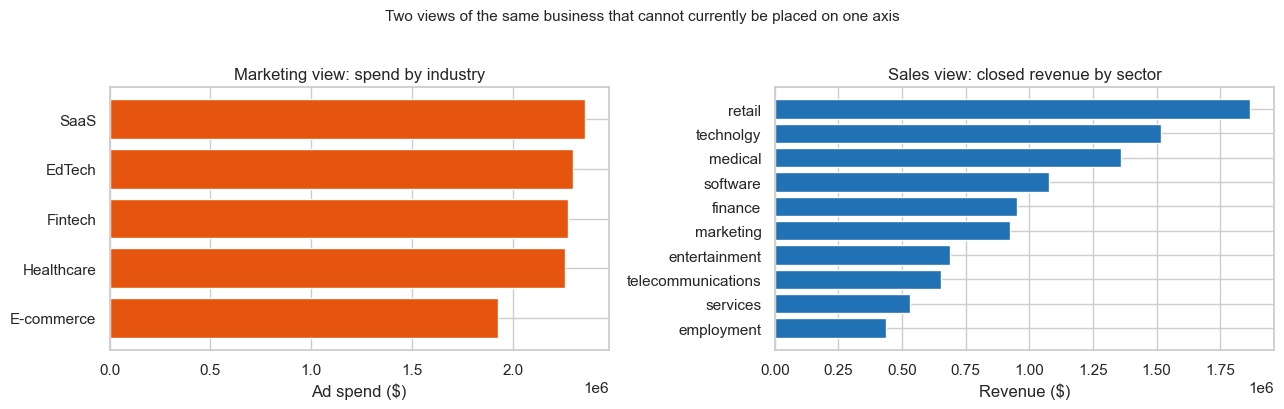

In [15]:
# Each system's ranking, side by side and unreconcilable
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

a = ads_by_industry.sort_values('ad_spend', ascending=True)
axes[0].barh(a['industry'], a['ad_spend'], color='#e6550d')
axes[0].set_title('Marketing view: spend by industry')
axes[0].set_xlabel('Ad spend ($)')

c = crm_by_sector.dropna(subset=['crm_revenue']).sort_values('crm_revenue', ascending=True)
axes[1].barh(c['sector'], c['crm_revenue'], color='#2171b5')
axes[1].set_title('Sales view: closed revenue by sector')
axes[1].set_xlabel('Revenue ($)')

plt.suptitle('Two views of the same business that cannot currently be placed on one axis',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

This pair of charts is the project in one image. Both are legitimate. Both are built from
clean data. **Neither can be laid over the other**, because the x-axes describe different
category systems — and so the question "are we spending where the revenue is?" has no answer.

---

## Step 7 — A second disagreement: the two systems do not agree on how much revenue exists

Everything above concerns the *join key*. There is a second, independent failure that the
0% match rate obscures, and it is arguably worse.

Both systems ship a column called **`revenue`**. We have been treating the CRM's as the
revenue measure (assumption A3) and quietly ignoring the ads table's. That was a modelling
choice, not an oversight — but leaving it unexamined would hide the finding.

The ad platform reports its own revenue and its own conversion count. Nobody in either
system is obliged to reconcile them, and nobody does.


In [16]:
# Both systems report "revenue" and "conversions". Put the two definitions side by side.
ads_revenue      = ads_by_industry['ad_revenue'].sum()
ads_conversions  = ads_by_industry['conversions'].sum()
crm_revenue      = crm_by_sector['crm_revenue'].sum()
crm_won_deals    = int(crm_by_sector['deals_won'].sum())

recon = pd.DataFrame([
    {'metric': 'Reported revenue',
     'ad platform': f"${ads_revenue:,.0f}",
     'CRM': f"${crm_revenue:,.0f}",
     'ratio': f"{ads_revenue / crm_revenue:.1f}x"},
    {'metric': 'Reported "successes"',
     'ad platform': f"{ads_conversions:,} conversions",
     'CRM': f"{crm_won_deals:,} won deals",
     'ratio': f"{ads_conversions / crm_won_deals:.0f}x"},
    {'metric': 'Implied value per success',
     'ad platform': f"${ads_revenue / ads_conversions:,.2f}",
     'CRM': f"${crm_revenue / crm_won_deals:,.2f}",
     'ratio': f"{(crm_revenue / crm_won_deals) / (ads_revenue / ads_conversions):.1f}x"},
]).set_index('metric')

print("=" * 74)
print("TWO SYSTEMS, TWO DEFINITIONS OF THE SAME WORD")
print("=" * 74)
print(f"Blended platform-reported ROAS: {ads_revenue / ads_by_industry['ad_spend'].sum():.2f}x")
print(f"Unexplained revenue gap:        ${ads_revenue - crm_revenue:,.0f}")
recon

TWO SYSTEMS, TWO DEFINITIONS OF THE SAME WORD
Blended platform-reported ROAS: 4.88x
Unexplained revenue gap:        $44,177,797


,ad platform,CRM,ratio
metric,,,
Reported revenue,"$54,183,331","$10,005,534",5.4x
"Reported ""successes""","326,812 conversions","4,238 won deals",77x
Implied value per success,$165.79,"$2,360.91",14.2x


### What this does and does not show

**It does not show that the ad platform is lying.** The two datasets cover different periods
(A1) and are independent sources; this is not a like-for-like audit of one company's numbers,
and the ratio should not be quoted as "platforms overstate revenue by 5.4x."

**What it shows is that the gap is unexplainable with the data available.** Two systems each
report a figure called revenue. They differ by **5.4x**. There is no field in either system
that reconciles them, no shared definition, and no owner of the difference. Ask "what is our
revenue?" and you get two defensible answers an order of magnitude apart, with no way to
adjudicate.

The likely reason — and it is a *hypothesis*, not something this data can confirm — is that
the two words mean different things:

| | Ad platform `revenue` | CRM `close_value` |
|---|---|---|
| Measures | Value attributed to a conversion event | Contracted value of a closed-won deal |
| Attribution | Self-reported by the vendor being paid | Recorded by the party doing the work |
| Window | Click/view lookback, set in the ad console | Deal close date |
| Counts | 326,812 conversions | 4,238 deals |
| Recognised when | The conversion pixel fires | The contract is signed |

The 77x gap in event counts is the clearer tell. A "conversion" in the ads table is any
tracked action — form fill, signup, add-to-cart. A "won deal" is a signed contract. These
were never the same unit, but both feed dashboards labelled *performance*.

### Why this belongs in the diagnosis

This is the **same root cause as the taxonomy mismatch, at a different layer**. The taxonomy
failure is two vocabularies for the same dimension. This is two definitions for the same
measure. Both arise from the same unowned seam — and note that the crosswalk in notebook 03
fixes the first and does **nothing** for the second.

That matters for how the fix is described. Reconciling the taxonomies lets the two systems be
placed on one axis. It does not make their revenue numbers mean the same thing. A shared
reference table needs to govern **metric definitions**, not just category values.


---

## Findings

| # | Finding | Evidence |
|---|---------|----------|
| 1 | Naive join match rate is **0%** | 0 of 15 outer-join rows matched on both sides |
| 2 | **100% of ad spend** unreconciled | \$0 of total spend matched to any CRM sector |
| 3 | **100% of closed revenue** unreconciled | \$0 of won revenue matched to any ads industry |
| 4 | Failure is **silent** | `pd.merge` succeeds; inner join returns empty, left join returns all-null columns |
| 5 | String normalisation recovers **nothing** | 4 normalisation strategies, 0 matches each |
| 6 | Fuzzy matching is **unreliable and confidently wrong** | Agrees with human judgement on only 1/5 values (`Fintech`→`finance`); the 4 errors include mapping `Healthcare`→`software` |
| 7 | Only **1 of 5** root causes is fixable in analysis | Remainder need instrumentation/schema/process change |
| 8 | The two systems report revenue figures **5.4x apart** | \$54.2M platform-reported vs \$10.0M CRM closed-won, with no field reconciling them |
| 9 | They also disagree on event counts by **77x** | 326,812 ads "conversions" vs 4,238 "won deals" — different units, same dashboards |

## What comes next

The crosswalk in notebook 03 addresses finding #7's single tractable item. It will **not**
produce a 100% match rate — `EdTech` has no CRM counterpart and several CRM sectors
(`employment`, `entertainment`, `telecommunications`) have no ads counterpart. Those are real
coverage gaps, not mapping mistakes, and the honest output preserves them rather than forcing
every value to match something.

The right target is *maximum defensible coverage*, not 100%.

Findings #8 and #9 are **out of scope for the crosswalk entirely**. Mapping `Fintech`→`finance`
does not make platform-reported revenue and closed-won revenue the same quantity. That gap is a
metric-definition problem and belongs in the README recommendation, not in the fix.

---

**Next:** `03_reconciliation.ipynb` — build the crosswalk, re-run the join, measure recovered coverage.

In [17]:
import os
os.makedirs('../output', exist_ok=True)

ads_by_industry.to_csv('../output/ads_by_industry.csv', index=False)
crm_by_sector.to_csv('../output/crm_by_sector.csv', index=False)

# Persist the naive-join result as the "before" baseline for notebook 04.
#
# DENOMINATOR DISCIPLINE — read before adding the "after" row in nb 04.
# The obvious match rate is `matched / len(merged)`, but len(merged) is a property of the
# *merge*, not of the business. Once the crosswalk collapses several sectors onto one
# industry, len(merged) changes, and a before/after chart built on it compares two different
# denominators while calling both "match rate". That chart would be wrong and would look fine.
#
# So: every rate below divides by a quantity fixed *before* any join runs —
#   category_match_rate -> ads_categories        (5, fixed)
#   ad_spend_coverage   -> ad_spend_total        ($11,108,749.09, fixed)
#   crm_revenue_coverage-> crm_revenue_total     ($10,005,534.00, fixed)
# The two money coverages are the headline numbers for the nb 04 comparison. They are
# denominator-stable by construction and they are what the business actually cares about.

baseline = pd.DataFrame([{
    'stage': 'naive_join',
    'ads_categories': n_ads_industries,
    'crm_categories': n_crm_sectors,
    'matched_categories': matched,
    'category_match_rate': matched / n_ads_industries,      # denom: ads categories, NOT len(merged)
    'ad_spend_total': total_spend,
    'ad_spend_matched': matched_spend,
    'ad_spend_coverage': matched_spend / total_spend,       # <- headline
    'crm_revenue_total': total_crm_rev,
    'crm_revenue_matched': matched_rev,
    'crm_revenue_coverage': matched_rev / total_crm_rev,    # <- headline
    'ads_reported_revenue': ads_revenue,                    # finding #8, carried forward
    'revenue_definition_gap': ads_revenue / total_crm_rev,
}])
baseline.to_csv('../output/baseline_naive.csv', index=False)

# Guard: the "after" row in nb 04 must reuse these exact denominators.
assert np.isclose(baseline['ad_spend_total'].iloc[0], 11_108_749.09), "ad spend denominator drifted"
assert np.isclose(baseline['crm_revenue_total'].iloc[0], 10_005_534.00), "crm revenue denominator drifted"

print("Saved:")
print("  output/ads_by_industry.csv")
print("  output/crm_by_sector.csv")
print("  output/baseline_naive.csv   <- 'before' baseline for the comparison in nb 04")
print("\nHeadline metrics for the nb 04 before/after chart (denominator-stable):")
print(f"  ad spend coverage:    {baseline['ad_spend_coverage'].iloc[0]:.1%}")
print(f"  crm revenue coverage: {baseline['crm_revenue_coverage'].iloc[0]:.1%}")
baseline.T

Saved:
  output/ads_by_industry.csv
  output/crm_by_sector.csv
  output/baseline_naive.csv   <- 'before' baseline for the comparison in nb 04

Headline metrics for the nb 04 before/after chart (denominator-stable):
  ad spend coverage:    0.0%
  crm revenue coverage: 0.0%


,0
stage,naive_join
ads_categories,5
crm_categories,10
matched_categories,0
category_match_rate,0.0
ad_spend_total,11108749.09
ad_spend_matched,0.0
ad_spend_coverage,0.0
crm_revenue_total,10005534.0
crm_revenue_matched,0.0
